In [1]:
import pandas as pd

dados = pd.read_csv("../data/dados_maquina.csv")

dados.head()

,temperatura,vibracao,corrente,pressao,horas_operacao,ciclos,falha
0,74.97,4.40,10.65,4.47,1019,27120,0
1,68.62,3.92,11.71,5.31,169,1078,0
2,76.48,3.06,10.42,5.67,4024,36891,1
3,85.23,2.35,11.38,7.51,2186,26473,1
4,67.66,3.70,8.21,6.45,2107,40832,0


In [2]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temperatura     1000 non-null   float64
 1   vibracao        1000 non-null   float64
 2   corrente        1000 non-null   float64
 3   pressao         1000 non-null   float64
 4   horas_operacao  1000 non-null   int64  
 5   ciclos          1000 non-null   int64  
 6   falha           1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


In [3]:
dados.describe()

,temperatura,vibracao,corrente,pressao,horas_operacao,ciclos,falha
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.193260,3.070880,12.011680,5.984950,2560.229000,25729.111000,0.370000
std,9.792202,0.997307,1.966908,0.821654,1420.152421,14157.929794,0.483046
min,37.590000,0.060000,5.960000,3.660000,104.000000,1021.000000,0.000000
25%,63.520000,2.390000,10.700000,5.410000,1264.000000,13389.500000,0.000000
50%,70.255000,3.060000,12.000000,6.000000,2598.000000,25738.000000,0.000000
75%,76.482500,3.730000,13.322500,6.532500,3834.750000,38161.250000,1.000000
max,108.530000,6.190000,19.850000,8.590000,4999.000000,49998.000000,1.000000


In [4]:
dados["falha"].value_counts()

falha
0    630
1    370
Name: count, dtype: int64

In [5]:
dados["falha"].value_counts(normalize=True) * 100

falha
0    63.0
1    37.0
Name: proportion, dtype: float64

Matplotlib is building the font cache; this may take a moment.


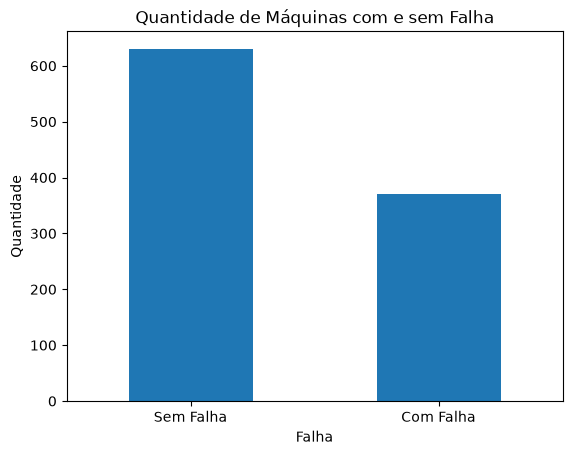

In [6]:
import matplotlib.pyplot as plt

dados["falha"].value_counts().plot(kind="bar")

plt.title("Quantidade de Máquinas com e sem Falha")
plt.xlabel("Falha")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Sem Falha", "Com Falha"], rotation=0)
plt.show()

In [7]:
dados.groupby("falha")[
    ["temperatura", "vibracao", "corrente", "pressao", "horas_operacao", "ciclos"]
].mean()

,temperatura,vibracao,corrente,pressao,horas_operacao,ciclos
falha,,,,,,
0,68.547778,2.889968,11.946206,5.943143,2090.674603,25874.115873
1,72.995027,3.378919,12.123162,6.056135,3359.740541,25482.210811


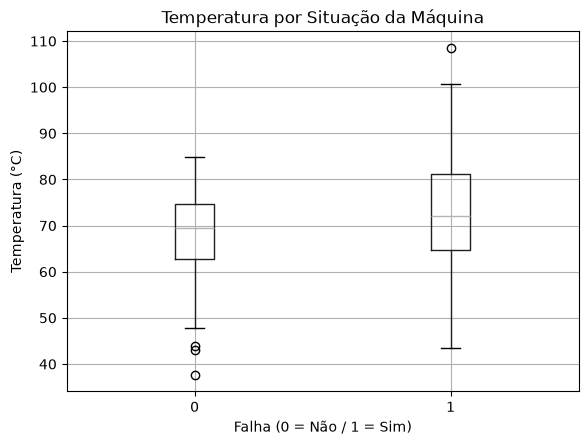

In [8]:
dados.boxplot(column="temperatura", by="falha")

plt.title("Temperatura por Situação da Máquina")
plt.suptitle("")
plt.xlabel("Falha (0 = Não / 1 = Sim)")
plt.ylabel("Temperatura (°C)")
plt.show()

In [9]:
dados.groupby("falha")[
    [
        "temperatura",
        "vibracao",
        "corrente",
        "pressao",
        "horas_operacao",
        "ciclos"
    ]
].mean()

,temperatura,vibracao,corrente,pressao,horas_operacao,ciclos
falha,,,,,,
0,68.547778,2.889968,11.946206,5.943143,2090.674603,25874.115873
1,72.995027,3.378919,12.123162,6.056135,3359.740541,25482.210811


In [10]:
dados.corr(numeric_only=True)

,temperatura,vibracao,corrente,pressao,horas_operacao,ciclos,falha
temperatura,1.000000,-0.040398,0.022072,-0.013375,0.038940,-0.016274,0.219381
vibracao,-0.040398,1.000000,-0.011202,-0.054660,-0.012014,-0.054087,0.236823
corrente,0.022072,-0.011202,1.000000,0.021620,-0.037421,-0.046951,0.043458
pressao,-0.013375,-0.054660,0.021620,1.000000,-0.050284,-0.011450,0.066428
horas_operacao,0.038940,-0.012014,-0.037421,-0.050284,1.000000,0.039212,0.431656
ciclos,-0.016274,-0.054087,-0.046951,-0.011450,0.039212,1.000000,-0.013371
falha,0.219381,0.236823,0.043458,0.066428,0.431656,-0.013371,1.000000


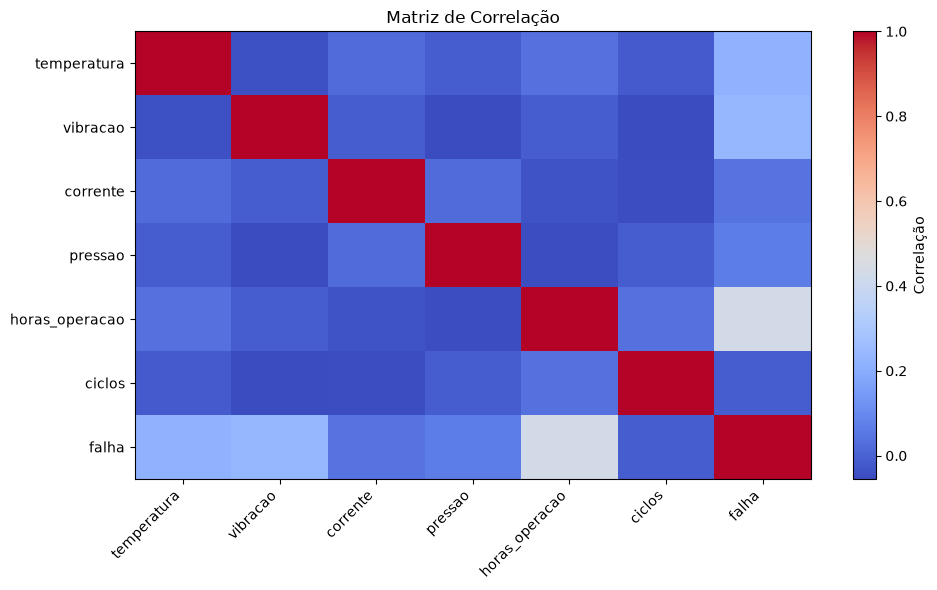

In [12]:
import matplotlib.pyplot as plt

correlacao = dados.corr(numeric_only=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    correlacao,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlação")

plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacao.columns)),
    correlacao.columns
)

plt.title("Matriz de Correlação")

plt.tight_layout()
plt.show()